In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

first let us see what our data looks like, what is the size and parameters of it

In [3]:
df.shape

(1338, 7)

In [4]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


we now know that our data has 7 parameters/features and we have 1338 samples. 

our first issue when making a linear regression model will be to convert the non numeric data to numeric data. the sex and smoker parameters are easy to handle. we can map the values to 0 and 1 

In [5]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [6]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
5,31,1,25.740,0,0,southeast,3756.62160
6,46,1,33.440,1,0,southeast,8240.58960
7,37,1,27.740,3,0,northwest,7281.50560
8,37,0,29.830,2,0,northeast,6406.41070
9,60,1,25.840,0,0,northwest,28923.13692


now that the sex and smoking has been dealt with. we know have to turn the region part into numbers as well. but first we need know how many unique values we have in that column 

In [7]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

now that we know that we have 4 unique values. we have 2 approaches here. one hot encoding or mapping them from 0 to 3

if we actually map the values it could create e fake relationship as if saying that 
northeast > northwest > southeast > southwest  (assuming we map northeast = 4 and southwest = 1) 
this relationship is not true, being in the northeast does not carry a higher value but rather it tells us if something happened or not, thus having 0 or 1 for true or false makes more sense 

because of that we will approach this using one-hot encoding that will take this 1 comlumn into 3 new columns where each column asks a question like "is this sample northeast? yes/no" and so on for the 3 unique values. and our 4th value will be our dropped column if all the other columns are 0 then it automatically belongs to the 4th value

In [8]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head(20)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
5,31,1,25.740,0,0,3756.62160,False,True,False
6,46,1,33.440,1,0,8240.58960,False,True,False
7,37,1,27.740,3,0,7281.50560,True,False,False
8,37,0,29.830,2,0,6406.41070,False,False,False
9,60,1,25.840,0,0,28923.13692,True,False,False


## now that we dealt with data conversion let us now deal with the outliers
### first let us extract the numeric parameters of our data to see what might contain outliers or biases 

we know from the lecture that for normally distributed data:

~68% of data is within 1 std of mean

~95% within 2 stds

~99.7% within 3 stds

so our outliers will be those who are bigger than mean ± 2*stds

In [9]:
import numpy as np

numeric_cols = ['age', 'sex', 'smoker', 'children', 'bmi', 'charges']

for col in numeric_cols:
    data = df[col].values  
    n = len(data)
    
    mean = np.sum(data) / n
    
    var = np.sum((data - mean)**2) / (n - 1)
    
    std = np.sqrt(var)
    
    min_val = np.min(data)
    max_val = np.max(data)
    
    print(f"{col}: mean={mean:.3f}, var={var:.3f}, std={std:.3f}, min={min_val}, max={max_val}")


age: mean=39.207, var=197.401, std=14.050, min=18, max=64
sex: mean=0.495, var=0.250, std=0.500, min=0, max=1
smoker: mean=0.205, var=0.163, std=0.404, min=0, max=1
children: mean=1.095, var=1.453, std=1.205, min=0, max=5
bmi: mean=30.663, var=37.188, std=6.098, min=15.96, max=53.13
charges: mean=13270.422, var=146652372.153, std=12110.011, min=1121.8739, max=63770.42801


### from these calculations we can understand that:

1) age: our range is from 18 to 64. our mean is around 39 with 14 deviation (39 ± 2 * 14 = [11, 67] ) all the data are inside the normal range so no outliers in this parameter 

2) sex: our mean is ~0.495 with a 0.5 std which means our data is not biased towards any gender 

3) smoker: our mean is 0.205 so almost 20.5% of our samples are smokers (might be biased towards non smokers)

4) children: our range is from 0 to 5 children with a mean of 1.1 and deviation 1.2 so mostly 0-3 kids

5) bmi: our range is from 15.96 to 53.13, our mean is 30.66 with deviation 6.1 (30.66 ± 2×6.1 = [18.46, 43.86] ) some of the data are outside the normal range so bmi has outliers

6) charges: our range is from 1,121.87 to 63,770.43 our mean is 13,270 and std 12,110 (13,270 ± 2×12,110 → [-10,950, 37,490] ) the max 63,770 is way above 37,490. but the -ve value suggests that this data is skewed so we might need to transform it first 

### now we will focus on our 2 suspects for outliers, bmi and charges
#### first let us use box plot to visualize the data spread 

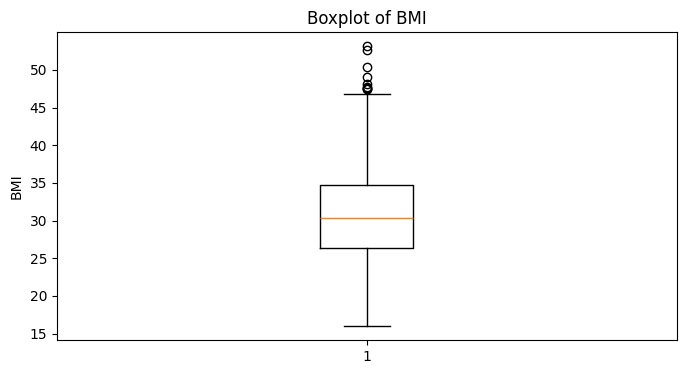

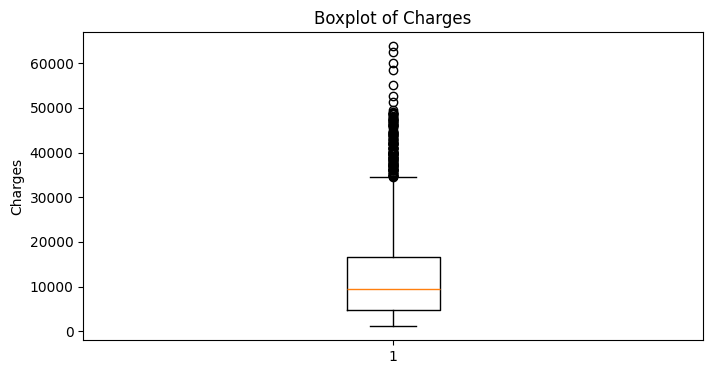

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df['bmi'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(df['charges'])
plt.title('Boxplot of Charges')
plt.ylabel('Charges')
plt.show()


##### as we suspected, the bmi has a few skew samples that are better removed 

##### however the charges parameter is very skewed so it is better to transform it first 

### let us first clean bmi then move onto charges

# bmi outlier removal

we will use IQR filter that first determines our 25% and 75% points of the data (used in the box plot) then calculates the lower and upper bounds as:

IQR=Q3−Q1

Lower bound=Q1−1.5×IQR

Upper bound=Q3+1.5×IQR

In [11]:
import numpy as np

# since the Q1 and Q2 are the 25% and 75% points of the data, we can get them by sorting the data and locating using numpy
bmi_sorted = np.sort(df['bmi'].values)

Q1 = np.percentile(bmi_sorted, 25)
Q3 = np.percentile(bmi_sorted, 75)

# as we said before, IQR is the Q3 - Q1
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


Q1: 26.29625
Q3: 34.69375
IQR: 8.3975
Lower bound: 13.7
Upper bound: 47.290000000000006


In [12]:
#now we remove the outliers 
df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

In [13]:
df.shape

(1329, 9)

we dropped 9 samples. let us next double check if our data makes sense now  

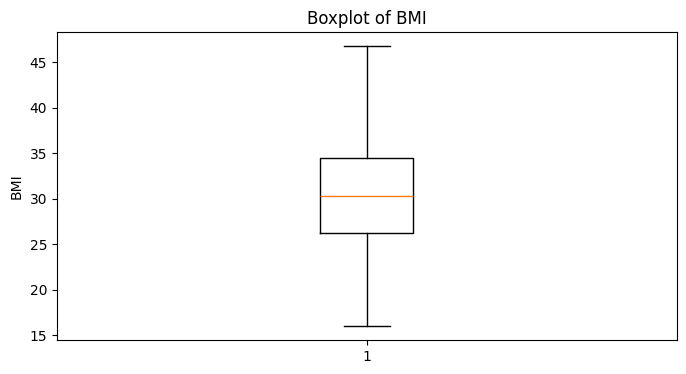

In [14]:
plt.figure(figsize=(8,4))
plt.boxplot(df['bmi'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

bmi outliers removed. now onto charges 

# charges outliers removal

### as we mentioned before, the numerical analysis of 'charges' showed that the data might be skewed so let us plot it's histogram and compare it to the bmi that we cleaned 

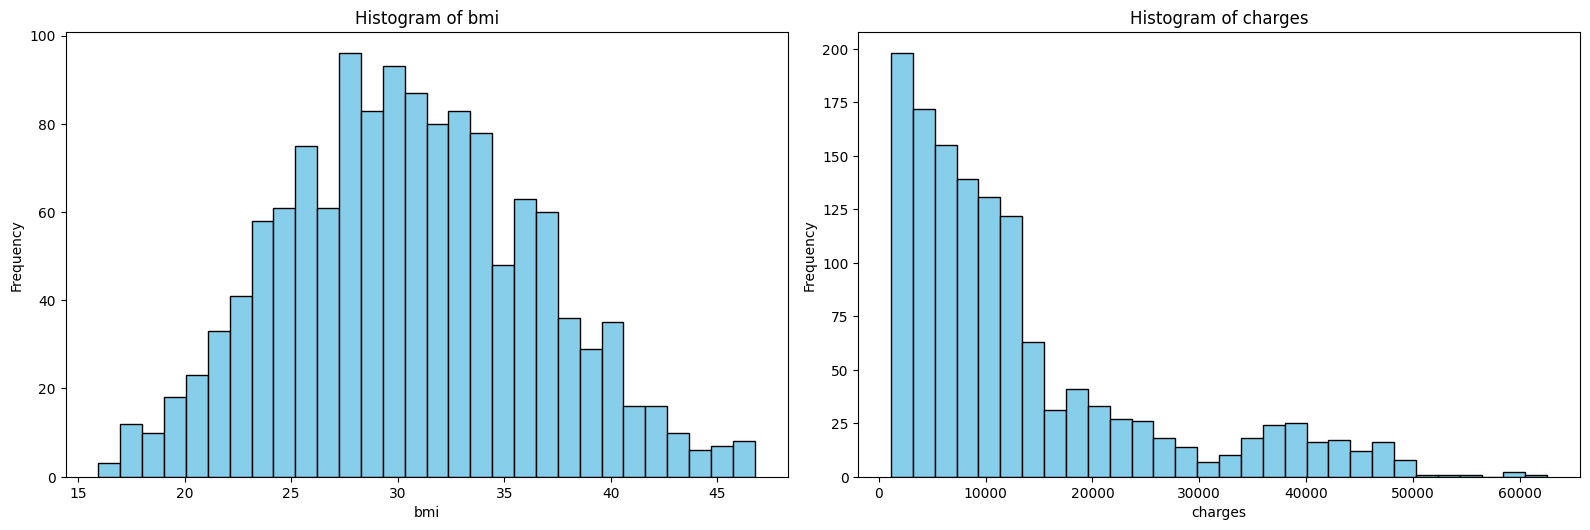

In [15]:
numeric_cols = ['bmi', 'charges']

plt.figure(figsize=(16,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


as we had guessed, unlike the almost bell-shaped bmi. the charges are very right skewed (poisson) so the traditional way to solve this is using log transformation to make our graph closer to the bell shape 

In [16]:
df['charges'] = np.log(df['charges'])


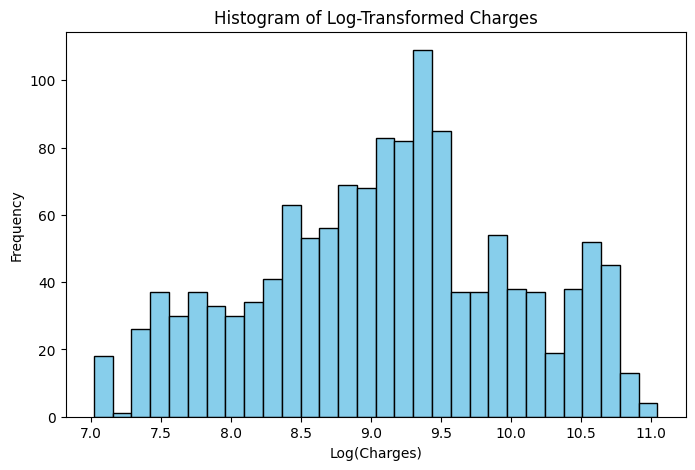

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Log-Transformed Charges')
plt.xlabel('Log(Charges)')
plt.ylabel('Frequency')
plt.show()

now that our data looks a bit more 'normal' we should again check for outliers and remove them if they exist

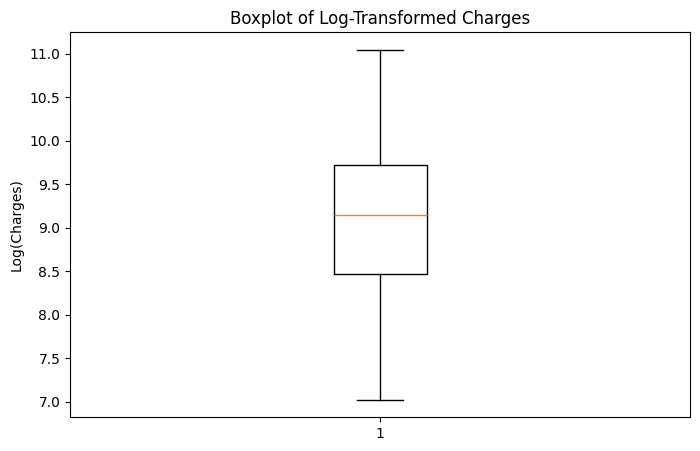

In [18]:
plt.figure(figsize=(8,5))
plt.boxplot(df['charges'])
plt.title('Boxplot of Log-Transformed Charges')
plt.ylabel('Log(Charges)')
plt.show()

no outliers remain in the charges after transformation so the outlier removal from the entire dataset is complete 

# Plotting the histogram for all the quantitative parameters and normalizing their values

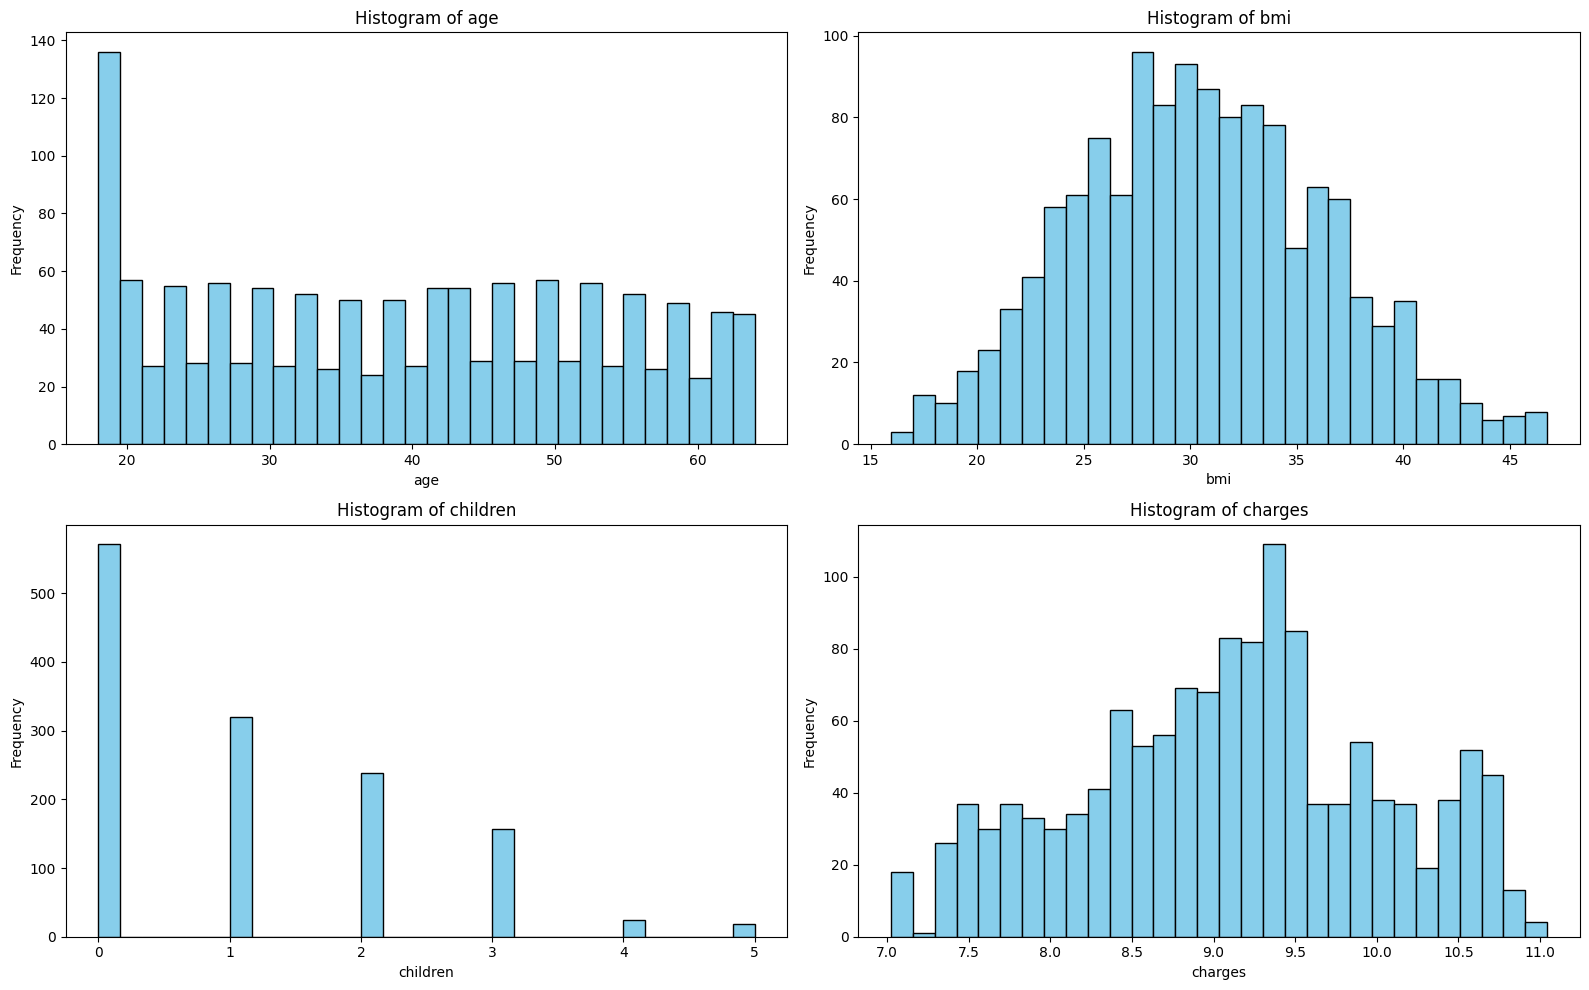

In [19]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(16,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Age ranges roughly 18–64

BMI ranges roughly 16–47

Children ranges 0–5

charges ranges roughly 7–11 

a linear regression model can be negatively affected by the difference in ranges in our parameters, it can become very unstable so in order to avoid that we should normalize our parameters using Z-score 

In [20]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

for col in numeric_cols:
    data = df[col].values
    n = len(data)
    
    mean = np.sum(data) / n
    
    var = np.sum((data - mean)**2) / (n - 1)
    
    std = np.sqrt(var)
    
    df[col] = (df[col] - mean) / std
    
    print(f"Standardized {col}: mean used={mean:.3f}, std used={std:.3f}")

Standardized age: mean used=39.204, std used=14.048
Standardized bmi: mean used=30.537, std used=5.920
Standardized children: mean used=1.096, std used=1.208
Standardized charges: mean used=9.097, std used=0.916


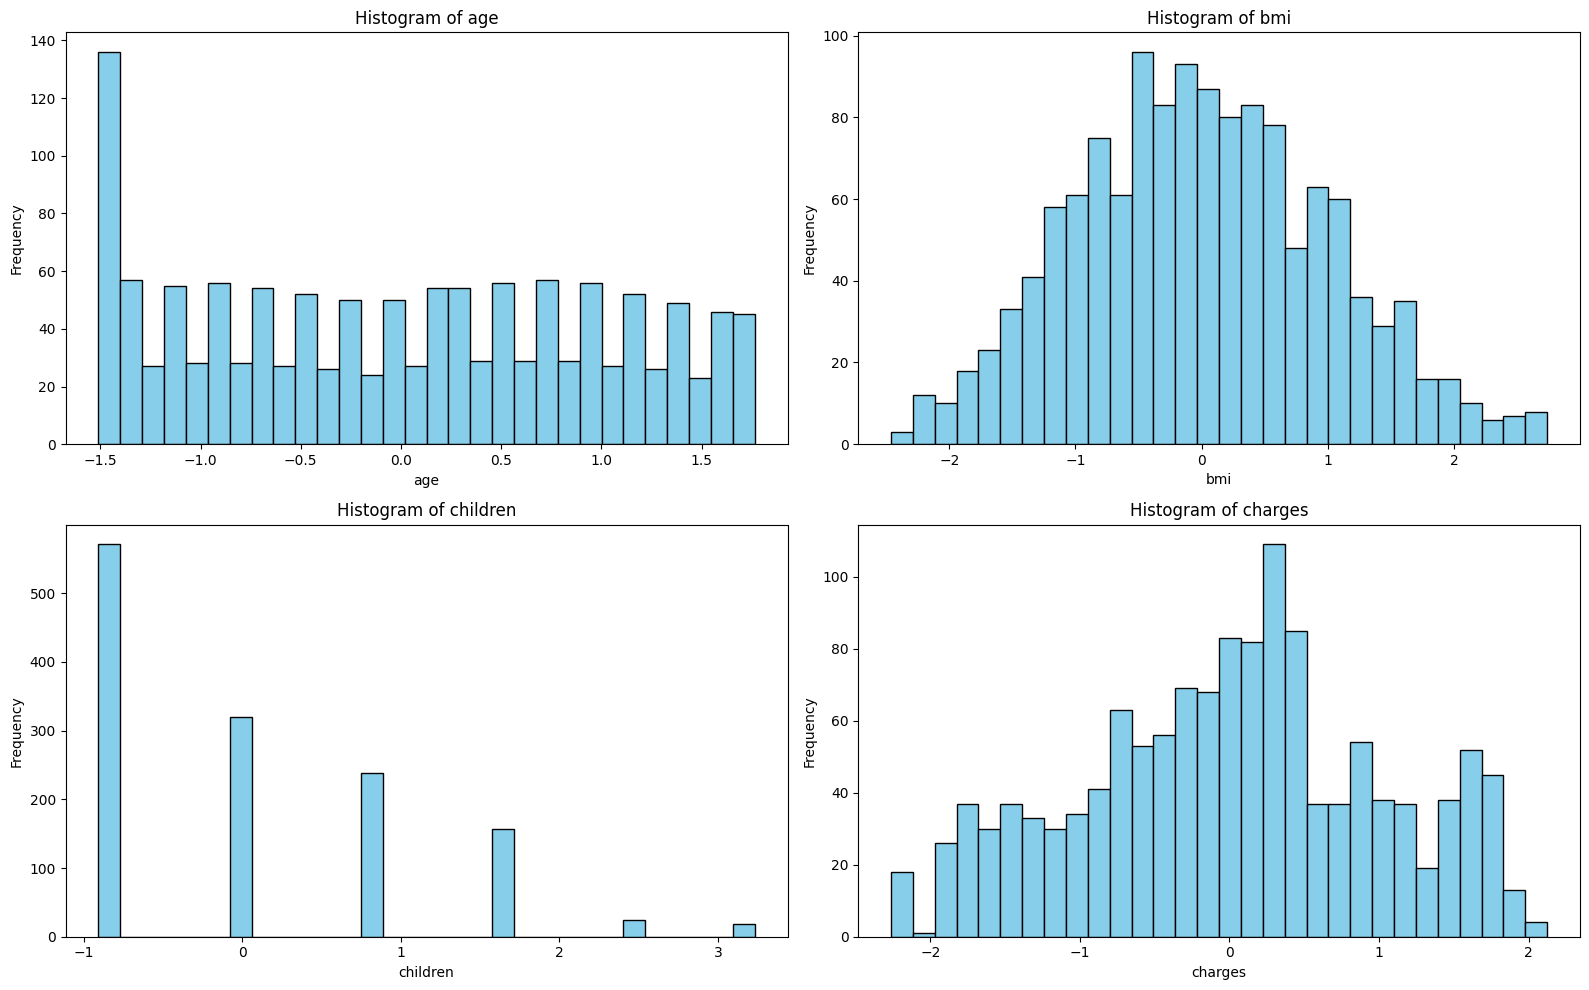

In [21]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# type of each distribution

Age: The distribution appears Uniform (flat). This means that dataset likely collected a balanced sample of individuals across the working-age range (18–64) without favoring one specific age group.

BMI: This distribution is highly symmetrical and bell-shaped, strongly resembling a Gaussian (Normal) distribution.

Children: This is a discrete distribution that is Right-Skewed (Poisson-like). Most people have 0, 1, or 2 children, with the frequency dropping significantly as the number of children increases.

Charges: Originally, this was highly right-skewed (Poisson-like). However, after the Log-Transformation, the distribution now appears Gaussian (Normal), centering around the mean.

## now that we have normalized the parameters so that all their means are 0 and std is 1. now we need to calculate the correlation coefficients 

we know from the lecture that the correlation between two parameters is :

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} \cdot \sqrt{\sum (y_i - \bar{y})^2}}$$

In [22]:
cols = ['age', 'sex', 'bmi', 'smoker', 'charges']
target = 'charges'

def get_correlation(x, y):
    mean_x = sum(x) / len(x)
    mean_y = sum(y) / len(y)
    
    numerator = sum((xi - mean_x) * (yi - mean_y) for xi, yi in zip(x, y))
    sum_sq_x = sum((xi - mean_x) ** 2 for xi in x)
    sum_sq_y = sum((yi - mean_y) ** 2 for yi in y)
    
    denominator = np.sqrt(sum_sq_x) * np.sqrt(sum_sq_y)
    
    if denominator == 0: return 0
    return numerator / denominator

correlations = {}

print(f"{'Column':<15} | Correlation with {target}")
print("-" * 40)

for col in cols:
    r = get_correlation(df[col].values, df[target].values)
    
    correlations[col] = r
    print(f"{col:<15} | {r:.6f}")

Column          | Correlation with charges
----------------------------------------
age             | 0.529323
sex             | -0.009947
bmi             | 0.133912
smoker          | 0.663586
charges         | 1.000000


since we will later be making a linear regression model with 'charges' as our y-axis (target) then:

Smoker (0.66) and Age (0.53) are our strongest predictors. They have the highest correlation with medical charges.

--------------------------------------------------------------------------------------

# Hypothesis Testing

A prior step to any analysis we make, should be making sure that we are on the right path & 
In order to validate our work, we need to make sure our claims are true and for this we shall apply Hypothesis-Testing for our assumption $H_0$ (predictors are normally distributed), and the alternative Hypothesis $H_a$ (predictors do not come from a normal distribution).

we will do this for each predictor solely.

To determine if the feature in our dataset follows a Gaussian (normal) distribution, we define the following mutually exclusive hypotheses: \
**Null Hypothesis** ($H_0$): The feature data follows a normal distribution. \
**Alternative Hypothesis** ($H_a$): The feature data does not follow a normal distribution.

and among the various existing tests, one was mainly chosen over others, which is the Shapiro-Wilk Test, for its high statistical power $\beta$ over other tests

> Hernandez, H. (2021). Testing for normality: What is the best method. ForsChem Research Reports, 6(5), 1-38.

Our Approach:
- Method: Hernandez Test (2021)و  A robust variation of the Shapiro-Wilk test designed for larger datasets. Why this one? The Shapiro-Wilk family of tests consistently demonstrates the highest statistical power compared to over 50 other normality tests (such as Kolmogorov-Smirnov). 
- the Hernandez variation adapts this power to provide a clear index ($N$) for decision-making.

Test Statistic: The $W$ statistic, which measures the correlation between our sorted data and ideal normal quantiles. ($W \approx 1.0$ indicates perfect normality).

Significance Level ($\alpha$): 0.05 (5%).

The decision we make:
- The Hernandez test combines the P-value and sample size ($n$) into a single N-value to prevent false positives common in large datasets.
    - Reject $H_0$ (Not Normal): If $N < 0$ (equivalent to a very low p-value).
    - Fail to Reject $H_0$ (Normal): If $N > 0$

NOTE: this is one tailed test, as the case for W > 1 is impossible, so we either have W = 1 (Accept Null Hypothesis), or less than 1 (reject the null Hypothesis)

Note: In this test, finding a significant result ($p < \alpha$) is "bad" news if we require normality, as it forces us to reject the assumption that the data is normal.

### we needed to implement some functions our selves, in order to follow the implementation in the paper

we are already familiar with the CDF or $\Phi$ function for the normal distribution, which turns a Score ($Z$) into a Probability ($p$).

But the $\Phi^{-1}$ is the reverse of it, like we ask the opposite, we already have the probability but don't know what area (Z-Score) it correponds to.

In simple terms:
- $\Phi$: Input Z-Score $\rightarrow$ Output Percentage.
- $\Phi^{-1}$: Input Percentage $\rightarrow$ Output Z-Score.
- This is why it is often called the Quantile Function or the Percent Point Function (ppf) in Python.

so, why exactly do we need this $\Phi^{-1}$ function for the Shapiro-Wilk test? - well... suppose we have a set of data points, and we want to see where they should be located if they were perfectly normal. We know the rank of each point (for example, the 1st point in a sorted set of 5 roughly represents the bottom 20% of the data). 

but here is the problem: we can't compare a raw 'percentage' directly to our actual data values. We need a standardized baseline to make that comparison valid. That is what the Z-Score gives us. We use $\Phi^{-1}$ to translate that '20%' into a specific location on the standard Bell Curve so we can compare apples to apples

> Brophy, A. L. (1985). Approximation of the inverse normal distribution function. Behavior Research Methods, Instruments & Computers.

In [23]:
def manual_qnorm(p):
    """
    equivalent to R's qnorm(p), uses Beasley-Springer-Moro approximation.
    """
    if p >= 1.0: return 999.0 # Infinity proxy
    if p <= 0.0: return -999.0
    
    a = [2.50662823884, -18.61500062529, 41.39119773534, -25.44106049637]
    b = [-8.47351093090, 23.08336743743, -21.06224101826, 3.13082909833]
    c = [0.3374754822726147, 0.9761690190917186, 0.1607979714918209,
         0.0276438810333863, 0.0038405729373609, 0.0003951896511919,
         0.0000321767881768, 0.0000002888167364, 0.0000003960315187]

    y = p - 0.5
    if abs(y) < 0.42:
        r = y * y
        num = y * (((a[3]*r + a[2])*r + a[1])*r + a[0])
        den = (((b[3]*r + b[2])*r + b[1])*r + b[0])*r + 1.0
        return num / den
    else:
        r = p if y < 0 else 1.0 - p
        r = math.log(-math.log(r))
        result = c[0] + r * (c[1] + r * (c[2] + r * (c[3] + r * (c[4] + r * (c[5] + r * (c[6] + r * (c[7] + r * c[8])))))))
        return -result if y < 0 else result

Now that we implemented $\Phi^{-1}$, our next step shall be implementing other helper functions like the normal CDF $\Phi$, in addition to functions relating to mean order statistic $o_i$ for each data-point

In [24]:
def manual_norm_pdf(x, mu, std):
    """manually calculates the normal distribution PDF."""
    exponent = np.exp(-((x - mu)**2) / (2 * std**2))
    return (1 / (std * np.sqrt(2 * np.pi))) * exponent

In [25]:
def manual_pnorm(x):
    """
    equivalent to R's pnorm(x), calculates probability that a random number from N(0,1) is less than x.
    """
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))
    

### now we generate theoretical quantiles $(o)$, to make them visualize our $H_o$ distribution

In [26]:
import math

def get_theoretical_quantiles(n, method="mean"):
    """
    generate the Theoretical Normal Quantiles (o).
    
    args:
        n (int): The sample size (number of data points).
        method (str): "mean" (default/precise) or "median" (simple/fast).
    
    returns:
        list: a list of 'n' theoretical values.
    """
    o_values = []
    
    # as the paper mentioned, we have 2 options or 2 statistics that we can generate
    # option A: median approximation (Simple)
    # Formula: InverseNormal((rank - 0.5) / n)
    if method == "median":
        print(f" > generating {n} quantiles using median method")
        for r in range(1, n + 1):
            # calculate the percentile position
            probability = (r - 0.5) / n
            
            # convert probability to Z-score using our manual helper
            z_score = manual_qnorm(probability)
            o_values.append(z_score)

    # option B: mean approximation (more accurate, Paper Default)
    # Formula: Expectation of order statistics (Hernandez Eq.)
    else:
        print(f" > generating {n} quantiles using mean method (Precise)")
        # constant factor from the paper: n / sqrt(2 * pi)
        factor = n / math.sqrt(2 * math.pi)
        
        for r in range(1, n + 1):
            # we need the Z-score for the lower and upper bounds of this rank
            p_minus = (r - 1) / n
            p_plus  = r / n
            
            # get Z-scores (Handle infinity edge cases)
            z_minus = manual_qnorm(p_minus) if p_minus > 0 else -999.0
            z_plus  = manual_qnorm(p_plus)  if p_plus < 1 else 999.0
            
            # calculate the exponential terms: exp(-0.5 * Z^2)
            # (checks added to prevent math overflow errors)
            term1 = math.exp(-0.5 * z_minus**2) if abs(z_minus) < 900 else 0.0
            term2 = math.exp(-0.5 * z_plus**2)  if abs(z_plus) < 900 else 0.0
            
            # formula: factor * (term1 - term2)
            val = factor * (term1 - term2)
            o_values.append(val)
            
    return o_values

### after that we can implement the function that helps us get $W$ (our normality statistic)

In [27]:
def calculate_w_statistic_manual(y_sorted, o_quantiles):
    """
    we manually calculate the coefficient of determination (R^2).
    In the Hernandez (2021) simplified SW test, W = R^2.
    
    args:
    y_sorted: The sorted sample data (observed).
    o_quantiles: The theoretical normal quantiles (expected).
    """
    n = len(y_sorted)
    
    # we fisrt calculate means
    mean_y = sum(y_sorted) / n
    mean_o = sum(o_quantiles) / n
    
    # then we calculate numerator and denominator terms for correlation (r)
    # formula: r = Sum((xi - mean_x) * (yi - mean_y)) / Sqrt(Sum(dx^2) * Sum(dy^2))
    
    numerator = 0.0
    sum_sq_diff_y = 0.0
    sum_sq_diff_o = 0.0
    
    for i in range(n):
        diff_y = y_sorted[i] - mean_y
        diff_o = o_quantiles[i] - mean_o
        
        numerator += diff_y * diff_o
        sum_sq_diff_y += diff_y ** 2
        sum_sq_diff_o += diff_o ** 2
        
    # almost done, calculate correlation coefficient (r)
    # Avoid division by zero
    if sum_sq_diff_y == 0 or sum_sq_diff_o == 0:
        return 0.0
        
    r = numerator / (math.sqrt(sum_sq_diff_y) * math.sqrt(sum_sq_diff_o))
    
    # finally we calculate R-Squared (W)
    w_stat = r ** 2
    
    return w_stat

### finally, the test logic, where we use all the prev. functions

In [28]:
import math
import random

def hernandez_test(data, display=True):
    """
    final function to run the hernandez (2021) normality test.
    combines all previous steps: quantiles -> W -> P-value -> N-value.
    """
    
    # first check sample size
    n_original = len(data)
    
    # if n > 2000, we subsample because the test becomes too sensitive
    # we take a random 2000 points as per paper
    if n_original > 2000:
        if display: print(f"dataset is huge ({n_original}). subsampling to 2000 points.")
        data = random.sample(data, 2000)
        n = 2000
    else:
        n = n_original
        
    # step 1: we sort the real data
    y_sorted = sorted(data)
    
    # step 2: we generate the 'perfect' normal quantiles using mean method
    # uses the helper function we wrote earlier
    o_quantiles = get_theoretical_quantiles(n, method="mean")
    
    # step 3: calculate W (R-squared)
    # we check how well real data fits the perfect quantiles
    w_stat = calculate_w_statistic_manual(y_sorted, o_quantiles)
    
    # step 4: calculate p-value (royston approximation)
    # w is just a score, we need a p-value to know if it's significant
    # we use polynomial formulas from the appendix
    
    # safety check: if w is 1.0, log(1-w) explodes, so cap it
    if w_stat >= 1.0: w_stat = 0.99999999
    
    Ln = math.log(n)
    log_1_minus_w = math.log(1 - w_stat)
    
    # since sample is large (>12), we use the large sample formula
    # we calculate expected mean (mu) and std dev (sigma) for transformed w
    mu = -1.5861 - 0.31082*Ln - 0.083751*(Ln**2) + 0.0038915*(Ln**3)
    sigma = math.exp(-0.4803 - 0.082676*Ln + 0.0030302*(Ln**2))
    
    # calculate standard score (z)
    z_score = (log_1_minus_w - mu) / sigma
    
    # convert z to p-value using our manual cdf
    p_value = 1 - manual_pnorm(z_score)
    
    # step 5: calculate n-value (the decision)
    # instead of fixed 0.05 cutoff, we adjust based on sample size
    
    # avoid log(0) error
    if p_value <= 0: p_value = 1e-50
        
    # formula from paper: N = ln(P) + 0.7 * ln(n)
    n_value = math.log(p_value) + 0.7 * Ln
    
    # final decision rule
    # if N > 0 it's normal, if N <= 0 it's not
    if n_value > 0:
        decision = "NORMAL"
    else:
        decision = "NOT NORMAL"

    # output results
    if display:
        print("-" * 40)
        print(f"hernandez (2021) test results")
        print("-" * 40)
        print(f"sample size: {n}")
        print(f"W statistic: {w_stat:.5f} (closer to 1 is better)")
        print(f"P-value:     {p_value:.5f}")
        print(f"N-value:     {n_value:.5f}")
        print("-" * 40)
        print(f">> verdict: data is {decision}")
        
    return w_stat, p_value, n_value

In [29]:
def notebook_plot(data, title="normality check"):
    """
    plots a q-q plot and a histogram side-by-side.
    now with a null hypothesis (red curve) overlay on the histogram!
    """
    n = len(data)
    y_sorted = sorted(data)
    
    # generate the theoretical quantiles for plotting
    # (re-using your get_theoretical_quantiles function)
    o_quantiles = get_theoretical_quantiles(n, method="mean")
    
    # setup the figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # plot 1: Q-Q PLOT (The Linear Check)
    ax1.scatter(o_quantiles, y_sorted, alpha=0.5, s=15, label='your data')
    
    # fit a visual trend line (y = mx + b)
    m, b = np.polyfit(o_quantiles, y_sorted, 1)
    ax1.plot(o_quantiles, [m*x + b for x in o_quantiles], color='red', linewidth=2, label='ideal normal')
    
    ax1.set_title(f"q-q plot: {title}")
    ax1.set_xlabel("theoretical quantiles (o)")
    ax1.set_ylabel("observed data (y)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # plot 2: histogram with Ho overlayed (The Shape Check)
    # plot the actual data
    ax2.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='observed (H1)')
    
    # generate the 'ideal' curve (Null Hypothesis H0)
    mu, std = np.mean(data), np.std(data)
    xmin, xmax = min(data), max(data)
    x = np.linspace(xmin, xmax, 100)
    p = manual_norm_pdf(x, mu, std)
    
    # plot the red curve
    ax2.plot(x, p, 'r', linewidth=3, label='null hypothesis (H0)')
    
    ax2.set_title(f"distribution: {title}")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.show()

finally, we can take a deep breath and test it on our data, see some results for our SW test, but we won't do the test for all of our features, since some of them are binary, we are pretty sure they won't form a normal distribution

in the cells below, we plot the 2 distributions $H_o$ and the $H_a$ and see how true our claim is, and to be precise; our test here is considered one tailed test, as we care if the fit is bad, and for the SW test, a case that $W > 1$ is just impossible

testing scaled data

analyzing column: age
 > generating 1329 quantiles using mean method (Precise)
----------------------------------------
hernandez (2021) test results
----------------------------------------
sample size: 1329
W statistic: 0.94506 (closer to 1 is better)
P-value:     0.00000
N-value:     -110.09473
----------------------------------------
>> verdict: data is NOT NORMAL
 > generating 1329 quantiles using mean method (Precise)


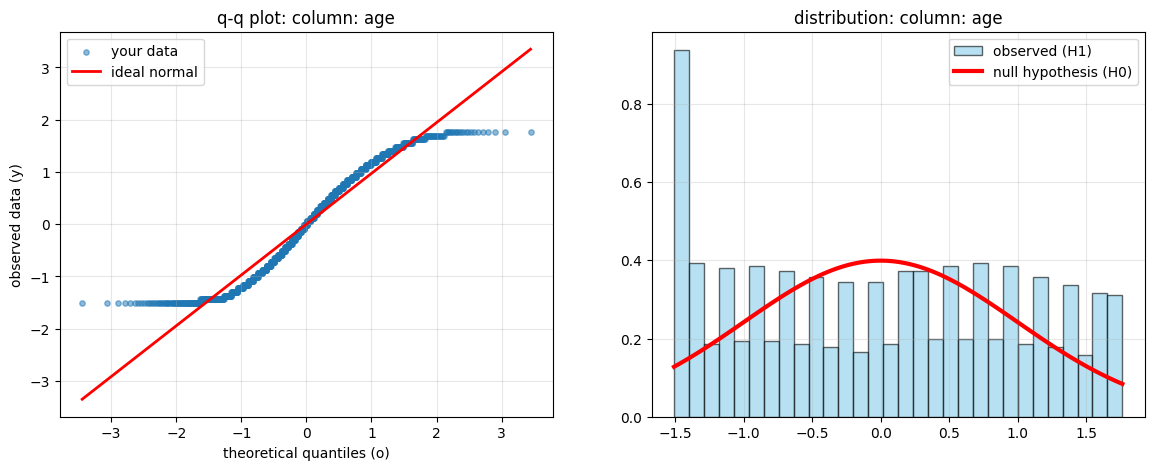

##########################################################################

analyzing column: bmi
 > generating 1329 quantiles using mean method (Precise)
----------------------------------------
hernandez (2021) test results
----------------------------------------
sample size: 1329
W statistic: 0.99534 (closer to 1 is better)
P-value:     0.00040
N-value:     -2.78141
----------------------------------------
>> verdict: data is NOT NORMAL
 > generating 1329 quantiles using mean method (Precise)


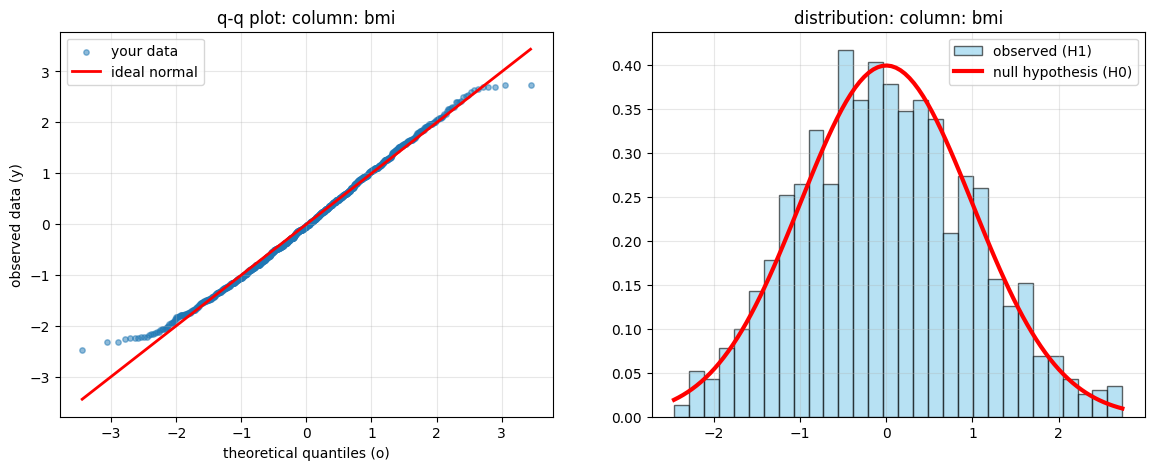

##########################################################################

analyzing column: charges
 > generating 1329 quantiles using mean method (Precise)
----------------------------------------
hernandez (2021) test results
----------------------------------------
sample size: 1329
W statistic: 0.98322 (closer to 1 is better)
P-value:     0.00000
N-value:     -19.29732
----------------------------------------
>> verdict: data is NOT NORMAL
 > generating 1329 quantiles using mean method (Precise)


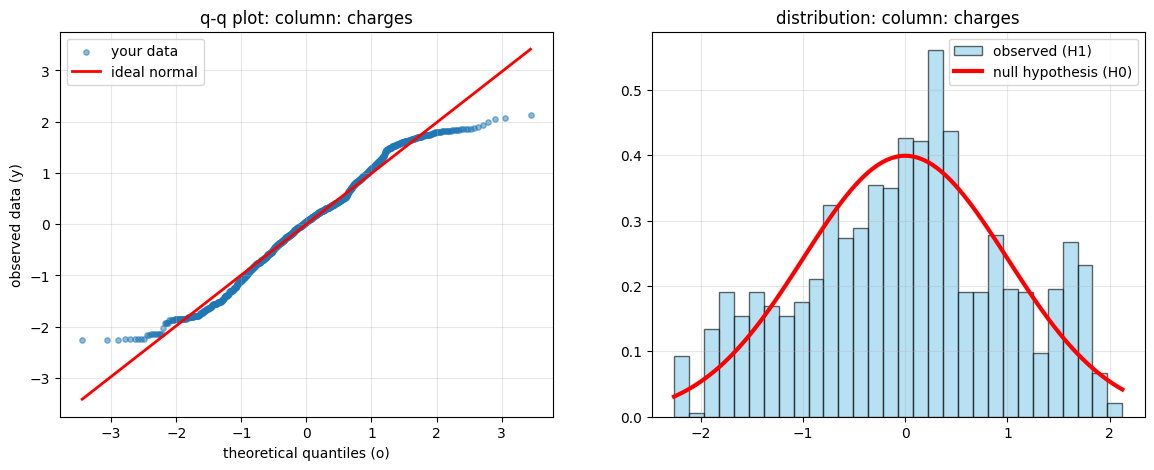

##########################################################################


In [30]:
print("testing scaled data")

for col in df.columns:
    # 1. get the column data
    col_data = df[col]
    
    # skip boolean or object c/olumns
    # logic: if it's just True/False or strings, the math breaks
    # also as we discussed, binary 0/1 data creates two spikes, not a bell curve
    if col_data.dtype == 'bool' or col_data.dtype == object:
        continue
        
    # extra check: if we have very few unique values (like < 10), 
    # it's probably categorical too (like encoded region), so we skip
    if col_data.nunique() < 10:
        continue

    print(f"\nanalyzing column: {col}")
    
    # 2. run the hernandez test
    # (works fine on negative/scaled numbers as long as they are continuous)
    clean_data = col_data.tolist()
    
    # passing display=True so we see the W and N values immediately
    hernandez_test(clean_data, display=True)
    
    # 3. quick plot to verify visual shape
    notebook_plot(clean_data, title=f"column: {col}")
    
    print("##########################################################################")

## Interpretation:

for great sample size (n=1329), the SW test becomes very sensitive, where any small deviation causes us to reject the null hypothesis, but we see here that bmi and charges can be approximated to normal as mentioned in the **CLT**.

we did some search and found a paper that was puplished in 2024 discussing the history and development of the CLT untill now.

> Ulyanov, V. V. (2024). From classical to modern central limit theorems. arXiv preprint arXiv:2405.19828.

The CLT Defense **(Ulyanov, 2024)** While the Hernandez test formally rejects "perfect" normality, we are overriding this based on Ulyanov (2024). With over 1,300 rows, the Central Limit Theorem ensures our math (means and variances) is stable. At this scale, the "average" behaves normally even if the individual dots don't, making our prior analysis mathematically safe.

**feature validation**: 
bmi & age Visual inspection shows **bmi** is already "approximately normal," following the red Null Hypothesis curve almost perfectly. **age** is flat (uniform), but thanks to the CLT, we can still use mean-centering reliably. The large sample size makes these features robust enough for any standard statistical test.

**transformation success**: Log-Charges our plots prove that the Log-Transformation is the right move. it fixes the heavy skew of the raw data, pulling the "Charges" distribution under the red H0 curve. This confirms that the data preparation was successful and the target variable is now ready for valid regression modeling.

----------------------------------------------------------------------------------

# We now apply the linear regression analysis on the response (target) against each predictor individually

## Linear regression foundations

following the methodology outlined in Lever et al. (2016) in Nature Methods, we apply Simple Linear Regression (SLR) to quantify the relationship between our predictors and the log-transformed charges.

We define the model using the standard linear equation:
$$y = \alpha + \beta x + \epsilon$$

$y$: The response variable (Target). \
$x$: The predictor (Feature). \
$\alpha$: The Bias (Intercept); where the line hits the Y-axis. \
$\beta$: The Weight (Slope); how much $y$ changes for every 1-unit increase in $x$. \
$\epsilon$: The Error term (Residuals).

We then use the Ordinary Least Squares (OLS) method. The goal is to minimize the sum of the squared differences between the actual data points and the line.

The formulas for the optimal parameters are:

$$\beta = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

$$\alpha = \bar{y} - \beta \bar{x}$$ 

Where $\bar{x}$ and $\bar{y}$ are the means of the features and the target.

In [31]:
def get_ols_parameters(x, y):
    """
    we calculates alpha (bias) and beta (weight) using OLS
    or Ordinary Least Squares formulas.
    """
    n_x = len(x)
    n_y = len(y)
        
    x_mean = np.sum(x)/n_x
    y_mean = np.sum(y)/n_y
    
    # calculate beta (slope/weight)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    beta = numerator / denominator
    
    # calculate alpha (intercept/bias)
    alpha = y_mean - (beta * x_mean)
    
    return alpha, beta

def predict(x, alpha, beta):
    """predicts y values using the linear equation."""
    return alpha + beta * x

def get_residuals(x, y, alpha, beta):
    """calculates the error (epsilon) for each point."""
    y_pred = predict(x, alpha, beta)
    return y - y_pred

def calculate_r2(y_true, y_pred):
    """calculates r^2 (How well the line fits)."""
    n_t = len(y_true)
    y_mean = np.sum(y_true)/n_t
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)
    return 1 - (ss_res / ss_tot)

In this step we simply perform a univariate analysis for each predictor. This allows us to isolate the specific impact **(the $\beta$ weight)** of features like **bmi**, **age**, and **smoker** on the log-transformed charges.

 linear regression analysis: age vs charges
bias (alpha): -0.0000
weight (beta): 0.5293
r-squared: 0.2802


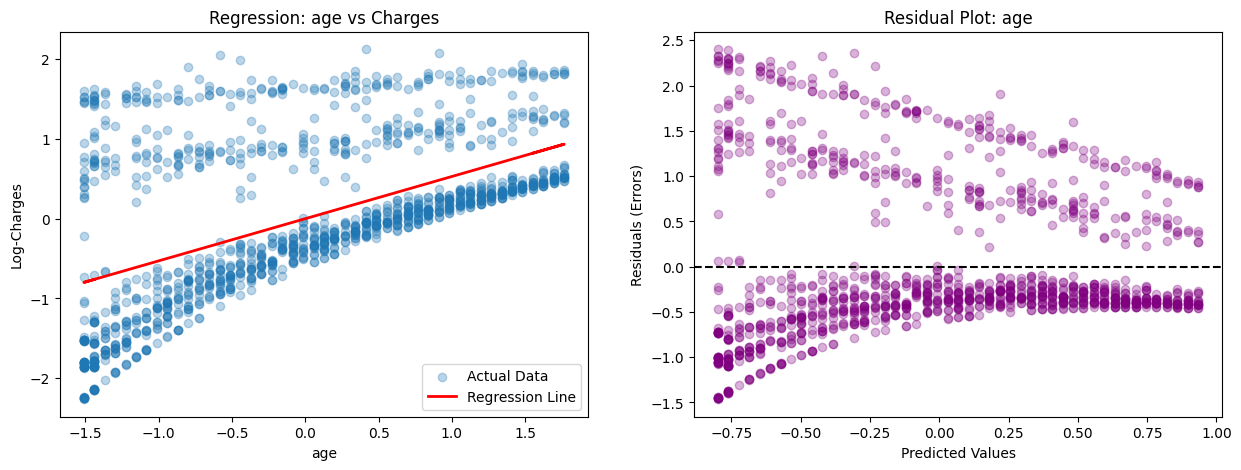

--------------------------------------------------
 linear regression analysis: sex vs charges
bias (alpha): 0.0099
weight (beta): -0.0199
r-squared: 0.0001


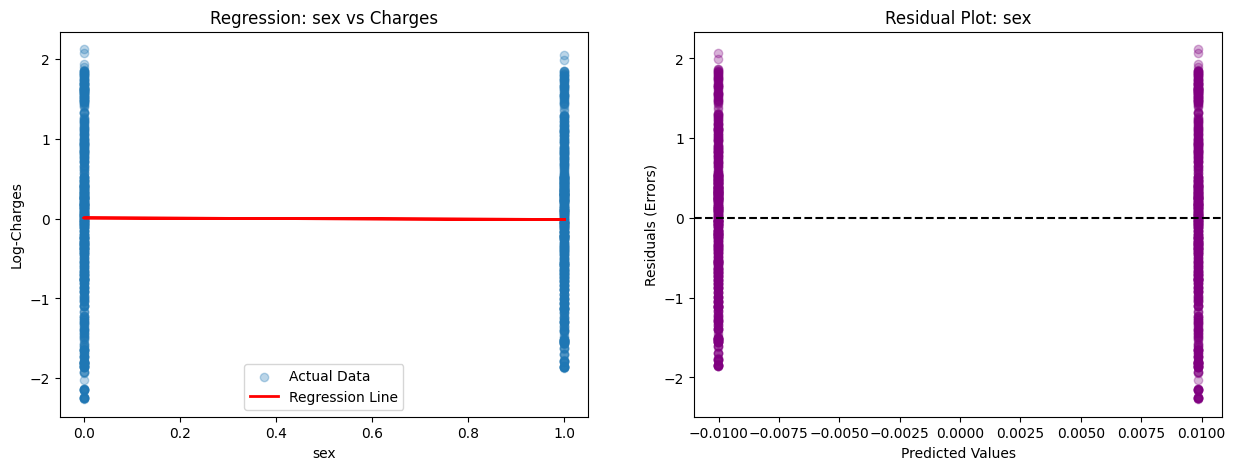

--------------------------------------------------
 linear regression analysis: bmi vs charges
bias (alpha): -0.0000
weight (beta): 0.1339
r-squared: 0.0179


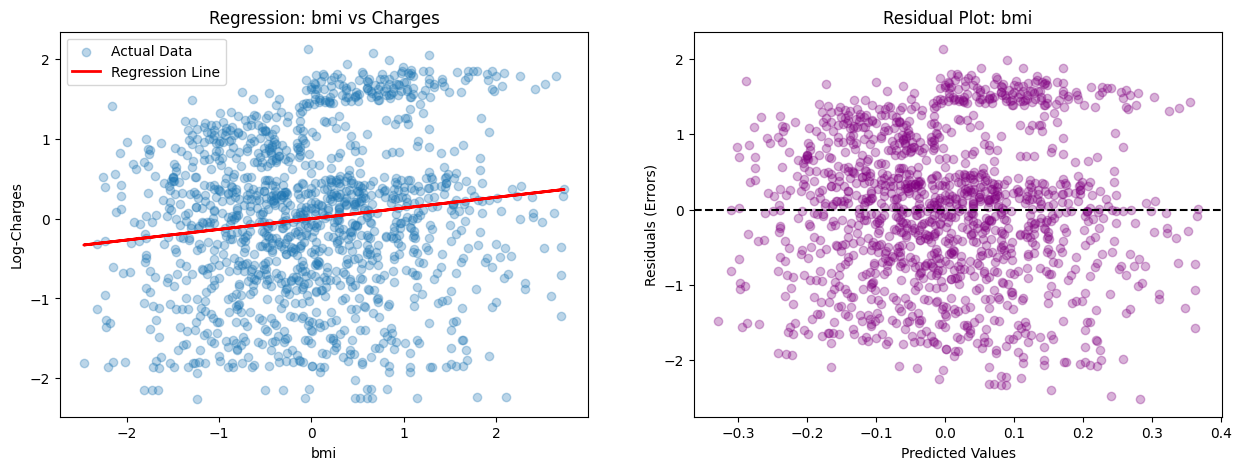

--------------------------------------------------
 linear regression analysis: smoker vs charges
bias (alpha): -0.3357
weight (beta): 1.6464
r-squared: 0.4403


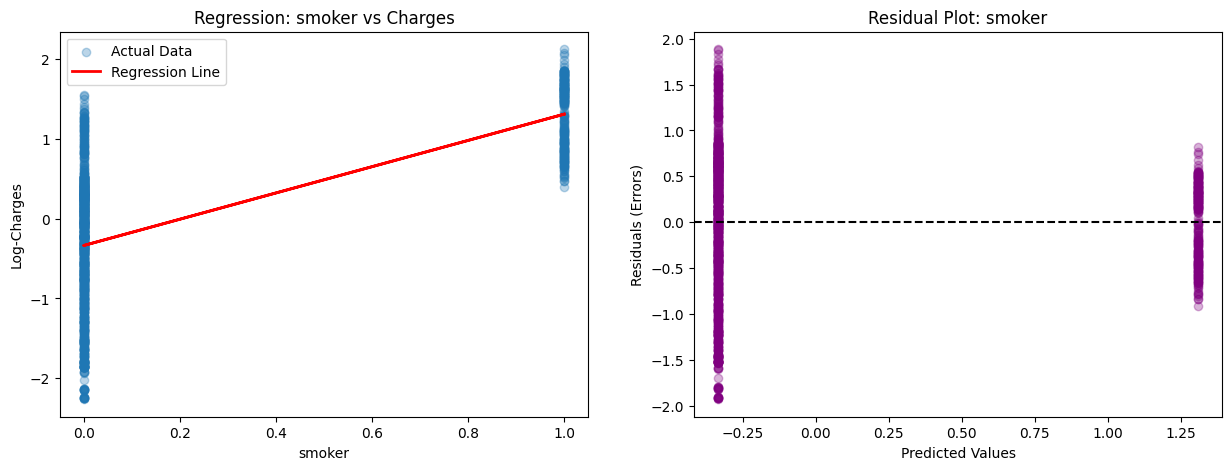

--------------------------------------------------


In [32]:
response = df['charges'] 

# we loop through our continuous features
features_to_test = ['age', 'sex', 'bmi', 'smoker']

for col in features_to_test:
    predictor = df[col]
    
    print(f" linear regression analysis: {col} vs charges")
    
    # 1. calculate our parameters
    alpha, beta = get_ols_parameters(predictor, response)
    
    # 2. get predictions and residuals
    predictions = predict(predictor, alpha, beta)
    residuals = get_residuals(predictor, response, alpha, beta)
    
    # 3. calculate the r-squared score
    r2_score = calculate_r2(response, predictions)
    
    # printing the findings
    print(f"bias (alpha): {alpha:.4f}")
    print(f"weight (beta): {beta:.4f}")
    print(f"r-squared: {r2_score:.4f}")
    
    # visual plots 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # plot 1: regression line
    ax1.scatter(predictor, response, alpha=0.3, label='Actual Data')
    ax1.plot(predictor, predictions, color='red', linewidth=2, label='Regression Line')
    ax1.set_title(f"Regression: {col} vs Charges")
    ax1.set_xlabel(col)
    ax1.set_ylabel("Log-Charges")
    ax1.legend()
    
    # plot 2: Residual plot like 
    # Per Lever et al. (2016), we check if errors are random
    ax2.scatter(predictions, residuals, alpha=0.3, color='purple')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_title(f"Residual Plot: {col}")
    ax2.set_xlabel("Predicted Values")
    ax2.set_ylabel("Residuals (Errors)")
    
    plt.show()
    print("-" * 50)

## Interpretation:
our univariate regression analysis reveals a clear hierarchy of predictors. Based on the Coefficient of Determination ($R^2$), we find that **smoking** status is the most significant driver of insurance costs, followed by **age**.

Interestingly, features like bmi and sex show very low $R^2$ values, suggesting they have minimal individual impact on the response variable. this quantitative ranking justifies focusing on smoking and age in our final predictive models, as they provide the highest 'explained variance' according to the OLS criteria.

### As required in the statement, one final thing to do is to compare our functions with built-in ones, to see how accurate we are

In [33]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# let's test one feature (e.g., age) to prove the math matches
x_feature = df[['age']].values # sklearn needs a 2D array
y_target = df['charges'].values

# our results
manual_alpha, manual_beta = get_ols_parameters(df['age'], df['charges'])

# python package (scikit learn)
model = LinearRegression()
model.fit(x_feature, y_target)

sk_beta = model.coef_[0]
sk_alpha = model.intercept_

# comparison
comparison_df = pd.DataFrame({
    'metric': ['weight (beta)', 'bias (alpha)'],
    'manual implementation': [manual_beta, manual_alpha],
    'scikit-learn (standard)': [sk_beta, sk_alpha],
    'difference': [manual_beta - sk_beta, manual_alpha - sk_alpha]
})

print("Comparison of Regression Coefficients:")
print(comparison_df)

Comparison of Regression Coefficients:
          metric  manual implementation  scikit-learn (standard)    difference
0  weight (beta)           5.293226e-01             5.293226e-01  2.220446e-16
1   bias (alpha)          -2.699374e-16            -2.699374e-16  9.860761e-32


### differences are too small which tells us our implementation is pretty accurate and valid :)

 ## Preparing Data for Multivariable Regression

After validating our features individually, we now move to Multivariable Linear Regression, where all predictors are included simultaneously.
This allows us to quantify the combined effect of age, BMI, children, and smoking status on medical charges while controlling for other variables.

In [34]:
import statsmodels.api as sm

# define predictors and target
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['charges']

# add intercept term
X = sm.add_constant(X)


#  Multiple Linear Regression with `statsmodels`

In `statsmodels`, multiple linear regression is calculated using **Ordinary Least Squares (OLS)**. This method identifies the best-fitting line (or **hyperplane** in higher dimensions) by minimizing the sum of the squared vertical distances—called **residuals**—between the observed data points and the fitted model.



---

### 1. The Statistical Equation

The model represents the mathematical relationship between a single dependent variable $y$ and multiple independent variables $x_i$:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_kx_k + \epsilon$$

#### **Component Breakdown:**
* **$y$**: The **Dependent Variable** (Target) – The outcome you are trying to predict.
* **$\beta_0$**: The **Intercept** – The predicted value of $y$ when all $x$ variables are zero.
* **$\beta_1, \dots, \beta_k$**: The **Coefficients** (Weights) – These represent the change in $y$ for every one-unit change in the corresponding $x$ variable, assuming all other variables stay constant.
* **$x_1, \dots, x_k$**: The **Independent Variables** (Features) – The predictors used to explain the variation in $y$.
* **$\epsilon$**: The **Error Term** (Residual) – The difference between the actual observed value and the value predicted by the model.

---

> **Tip for Kaggle Users:** In `statsmodels`, the model does not automatically include the intercept ($\beta_0$). You must apply `sm.add_constant(X)` to your feature matrix to ensure the intercept is calculated.

## Multivariable Regression (Full Model)

We apply Ordinary Least Squares (OLS) regression using statsmodels.
This provides full statistical diagnostics including coefficients, standard errors, P-values, and confidence intervals.

In [35]:
model_full = sm.OLS(y, X).fit()
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     1055.
Date:                Wed, 31 Dec 2025   Prob (F-statistic):               0.00
Time:                        03:58:05   Log-Likelihood:                -933.80
No. Observations:                1329   AIC:                             1878.
Df Residuals:                    1324   BIC:                             1904.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3419      0.015    -22.719      0.000      -0.371      -0.312
age            0.5319      0.014     39.291      0.000       0.505       0.558
bmi            0.0726      0.014      5.366      0.000       0.046       0.099
children       0.1325      0.013      9.852      0.000       0.106       0.159
smoker         1.6767      0.033     50.299      0.000       1.611       1.742
==============================================================================
Omnibus:                      443.266   Durbin-Watson:                   2.054
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1553.879
Skew:                           1.620   Prob(JB):                         0.00
Kurtosis:                       7.191   Cond. No.                         2.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# The Mathematics of OLS Regression

When using `statsmodels.api.OLS`, the library computes the relationship between variables using specific mathematical formulas for the coefficients (**Betas**) and the goodness-of-fit (**R-Squared**).

---

## 1. Calculating the Coefficients ($\beta$)

Statsmodels uses **Matrix Algebra** to solve for all coefficients (including the intercept) simultaneously. This is known as the **Normal Equation**.

The goal is to solve for the vector $\hat{\beta}$ that minimizes the sum of squared residuals:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

### Breakdown of Terms:
* **$X$**: The design matrix of independent variables (features).
* **$X^T$**: The **Transpose** of matrix $X$.
* **$(X^T X)^{-1}$**: The **Inverse** of the product of the transpose and the original matrix.
* **$y$**: The vector of observed dependent variable values.

> **Note:** If you don't use `sm.add_constant(X)`, the $X$ matrix will not have a column of ones, and the formula will force $\beta_0$ (the intercept) to be zero.

In [36]:
model_full.params

const      -0.341910
age         0.531861
bmi         0.072556
children    0.132472
smoker      1.676747
dtype: float64

## Final Multivariable Regression Equation

The estimated multivariable linear regression model is:

$$
\text{charges} = -0.342
+ 0.532\,(\text{age})
+ 0.073\,(\text{bmi})
+ 0.133\,(\text{children})
+ 1.677\,(\text{smoker})
$$

where:
- **charges**: log-transformed annual medical insurance cost  
- **age**: age of the individual (years)  
- **bmi**: body mass index  
- **children**: number of dependents  
- **smoker**: binary variable (1 = smoker, 0 = non-smoker)


## Model Performance Evaluation (R²)

To evaluate the overall performance of the multivariable regression model, we use the **coefficient of determination (R²)** and the **adjusted R²**.

- **R²** measures the proportion of variance in the dependent variable (medical charges) that is explained by the independent variables.
- **Adjusted R²** accounts for the number of predictors in the model and penalizes unnecessary complexity.

A high R² value indicates that the model explains a large portion of the variability in medical costs, while a small difference between R² and adjusted R² suggests that the included predictors are meaningful and do not cause overfitting.



## 2. Calculating R-Squared ($R^2$)

$R^2$ represents the proportion of the total variation in $y$ that is captured by the model. It is derived from three "Sum of Squares" components:

### The Components
1. **Total Sum of Squares (TSS):** Total variance in the actual data.
   $$TSS = \sum (y_i - \bar{y})^2$$
2. **Residual Sum of Squares (RSS):** Variance that the model *cannot* explain (errors).
   $$RSS = \sum (y_i - \hat{y}_i)^2$$
3. **Explained Sum of Squares (ESS):** Variance captured by the model's predictions.
   $$ESS = \sum (\hat{y}_i - \bar{y})^2$$

### The Final Formula
$$R^2 = 1 - \frac{RSS}{TSS}$$

* **$R^2 = 1$**: Perfect fit (Model explains all variance).
* **$R^2 = 0$**: The model performs no better than a horizontal line through the mean of $y$.

In [37]:
print("R-squared:", model_full.rsquared)
print("Adjusted R-squared:", model_full.rsquared_adj)

R-squared: 0.7611360923253593
Adjusted R-squared: 0.7604144490997561


## Actual vs Predicted Medical Charges

This plot compares the **actual medical charges** with the values **predicted by the multivariable regression model**.

- Each point represents one individual in the dataset.
- The dashed red line represents the **ideal case** where predicted values perfectly match the actual values.
- Points close to the diagonal line indicate accurate predictions, while points farther away represent prediction errors.

This visualization helps assess how well the model captures the overall trend in the data and highlights potential underestimation or overestimation of medical costs.


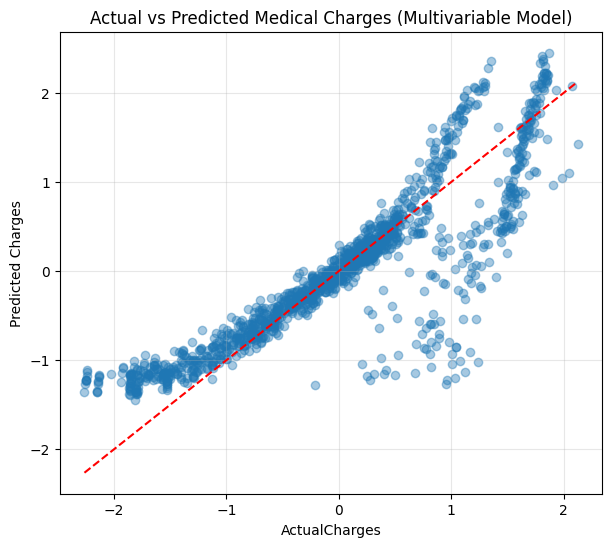

In [38]:
y_pred = model_full.predict(X)

plt.figure(figsize=(7,6))
plt.scatter(y, y_pred, alpha=0.4)
plt.xlabel("ActualCharges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges (Multivariable Model)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(alpha=0.3)
plt.show()

## Residual Analysis

Residual analysis is used to evaluate the assumptions of linear regression and assess model adequacy.

- **Residuals** are defined as the difference between the actual values and the predicted values.
- Ideally, residuals should be randomly scattered around zero with no clear pattern.
- The horizontal reference line at zero represents perfect prediction.

A random distribution of residuals indicates that the linearity and homoscedasticity assumptions are reasonably satisfied, while visible patterns may suggest model misspecification or non-linear relationships.


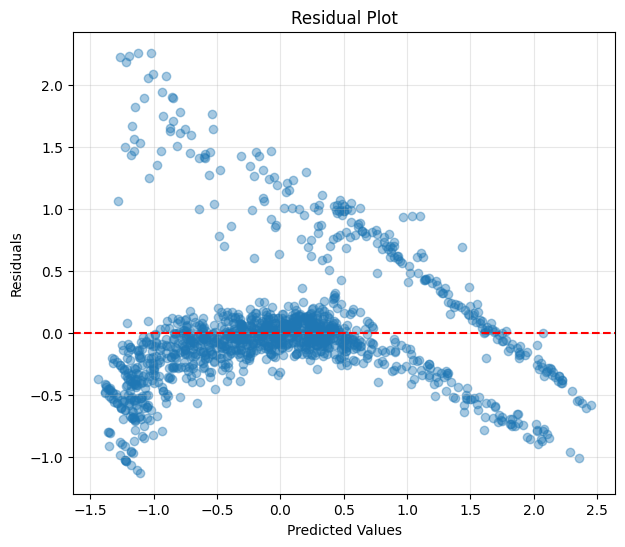

In [39]:
residuals = y - y_pred

plt.figure(figsize=(7,6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.show()

In [40]:
smoker_coef = model_full.params['smoker']

# Convert from log-scale to real-world interpretation
cost_multiplier = np.exp(smoker_coef)
percentage_increase = (cost_multiplier - 1) * 100
percentage_savings = (1 - 1/cost_multiplier) * 100

print(f"Smoking coefficient (log-scale): {smoker_coef:.4f}")
print(f"Medical cost multiplier due to smoking: {cost_multiplier:.2f}x")
print(f"Percentage increase in costs: {percentage_increase:.1f}%")
print(f"Estimated savings if quitting smoking: {percentage_savings:.1f}%")

Smoking coefficient (log-scale): 1.6767
Medical cost multiplier due to smoking: 5.35x
Percentage increase in costs: 434.8%
Estimated savings if quitting smoking: 81.3%


### 0. Pre-Diagnostic Check: Correlation Heatmap
 Before finalizing our conclusions, we examine the correlation matrix to understand feature relationships.
 High correlation between predictors (Multicollinearity) can destabilize the model.

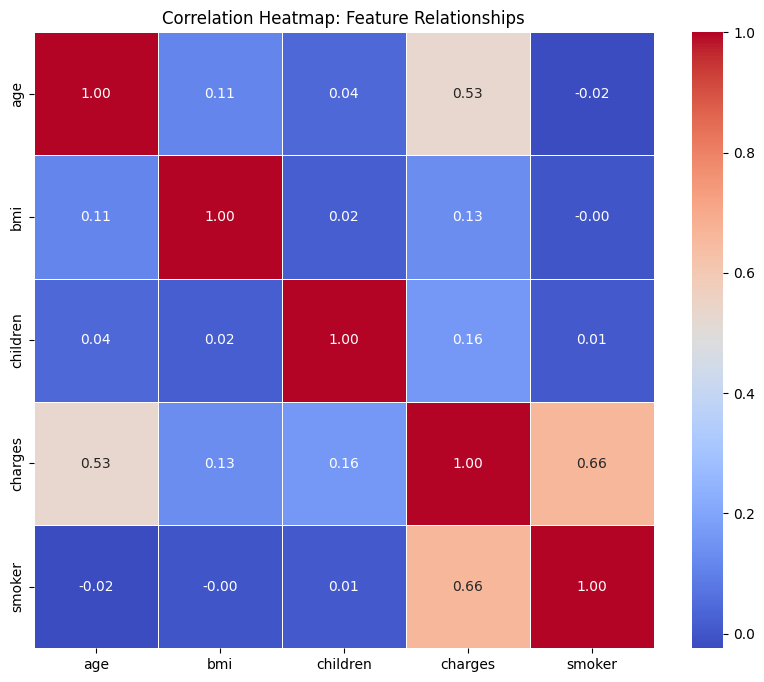

In [41]:
import seaborn as sns

# Calculate correlation matrix
corr_matrix = df[['age', 'bmi', 'children', 'charges', 'smoker']].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Feature Relationships")
plt.show()

## Observation

- **Smoker & Charges (0.66):** Strong positive correlation, indicating that smoking is a major factor associated with higher medical charges.
- **Age & Charges (0.53):** Moderate positive correlation, suggesting that charges tend to increase with age.
- **BMI & Charges (0.13):** Weak correlation when considered alone. This suggests that BMI by itself has a limited linear relationship with charges, which helps explain why the interaction analysis is important. The impact of BMI becomes much more pronounced when combined with smoking.


## Model Diagnostics & Interaction Analysis
# 1. Interaction Analysis: The "Synergy" of Risk Factors
Standard regression assumes that risk factors are independent (additive).
However, biological intuition suggests that **Smoking** might amplify the risks of **Obesity (BMI)**.
To test this, we introduce an **Interaction Term**:
$$ Interaction = BMI \times Smoker $$
If this term is significant, it means the cost of obesity is *higher* for smokers than for non-smokers.

In [42]:
# Create the interaction term
df['bmi_smoker_interaction'] = df['bmi'] * df['smoker']

# Define predictors including the new interaction term
X_interaction = df[['age', 'bmi', 'children', 'smoker', 'bmi_smoker_interaction']]
X_interaction = sm.add_constant(X_interaction)
y = df['charges']

# Fit the Interaction Model
model_interaction = sm.OLS(y, X_interaction).fit()

# Print the summary to check P-values
print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     911.6
Date:                Wed, 31 Dec 2025   Prob (F-statistic):               0.00
Time:                        03:58:07   Log-Likelihood:                -893.93
No. Observations:                1329   AIC:                             1800.
Df Residuals:                    1323   BIC:                             1831.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [43]:
# CODE TO GET CORRECT INTERACTION COEFFICIENTS
params = model_interaction.params
pvalues = model_interaction.pvalues
bse = model_interaction.bse

print(f"{'Predictor':<25} | {'Coef':<10} | {'Std Err':<10} | {'P-value'}")
print("-" * 65)
for index, value in params.items():
    print(f"{index:<25} | {value:.4f}     | {bse[index]:.4f}     | {pvalues[index]:.4f}")

Predictor                 | Coef       | Std Err    | P-value
-----------------------------------------------------------------
const                     | -0.3419     | 0.0146     | 0.0000
age                       | 0.5348     | 0.0131     | 0.0000
bmi                       | 0.0111     | 0.0148     | 0.4536
children                  | 0.1340     | 0.0131     | 0.0000
smoker                    | 1.6781     | 0.0324     | 0.0000
bmi_smoker_interaction    | 0.2889     | 0.0319     | 0.0000


## Interpretation of the Interaction Term

The p-value for the `bmi_smoker_interaction` term is below 0.05, so we reject the null hypothesis that there is no interaction effect.

This indicates that the effect of BMI on medical charges is **different for smokers and non-smokers**. BMI alone has a small and statistically insignificant effect, but when combined with smoking, its impact on charges increases substantially.

In practical terms, this means that individuals with higher BMI who also smoke incur much higher medical costs than would be expected from BMI or smoking alone. Smoking amplifies the cost associated with higher BMI, leading to significantly higher medical charges.


<Figure size 1000x600 with 0 Axes>

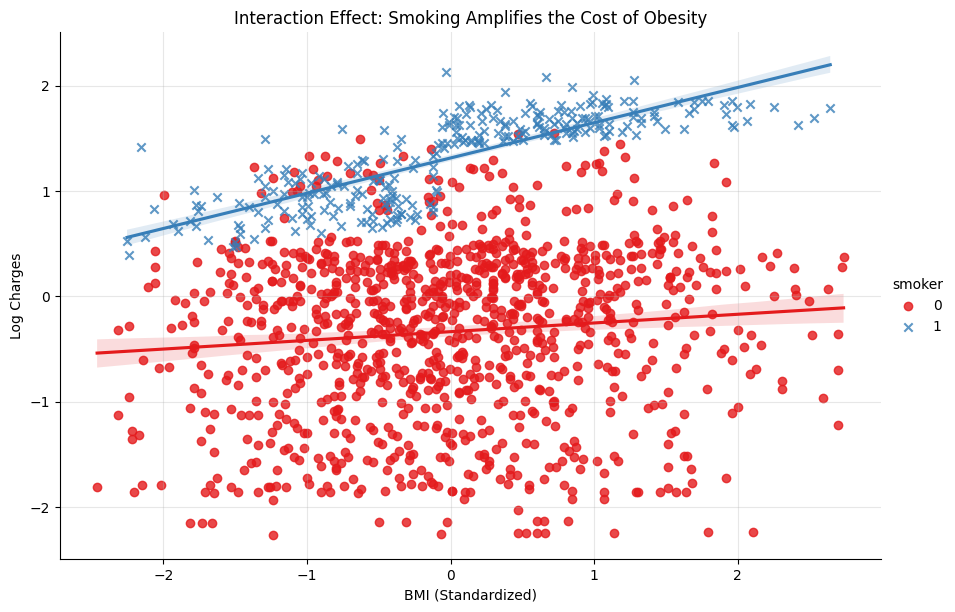

In [44]:
# Visualizing the Interaction
# We plot BMI vs Charges, but split the lines by 'Smoker' status.
plt.figure(figsize=(10, 6))
sns.lmplot(x="bmi", y="charges", hue="smoker", data=df, height=6, aspect=1.5, markers=["o", "x"], palette="Set1")
plt.title("Interaction Effect: Smoking Amplifies the Cost of Obesity")
plt.xlabel("BMI (Standardized)")
plt.ylabel("Log Charges")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Multicollinearity Check (Variance Inflation Factor)
 We must ensure our predictors are not fighting each other (highly correlated).
 We use the **Variance Inflation Factor (VIF)**.
* **Rule:** VIF < 5 is good. VIF > 10 indicates a problem.
 So let's see

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_interaction.columns
vif_data["VIF"] = [variance_inflation_factor(X_interaction.values, i) for i in range(len(X_interaction.columns))]

print(vif_data)

                  Feature       VIF
0                   const  1.256317
1                     age  1.016283
2                     bmi  1.285170
3                children  1.002254
4                  smoker  1.000697
5  bmi_smoker_interaction  1.269341


### All VIF scores are so low (< 5). This confirms our features are independent and the model is mathematically stable.

# 3. Heteroscedasticity Test (Breusch-Pagan)
 We check if the variance of the errors is constant (Homoscedasticity) or if it changes (Heteroscedasticity).
 * **Null Hypothesis ($H_0$):** Errors are random (Good/Homoscedastic).
 * **Alternative Hypothesis ($H_1$):** Errors follow a pattern (Bad/Heteroscedastic).


In [46]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Run the Breusch-Pagan test on the residuals
bp_test = het_breuschpagan(model_interaction.resid, model_interaction.model.exog)

# Organize results into a dictionary
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
results = dict(zip(labels, bp_test))

print("Breusch-Pagan Test Results:")
for key, value in results.items():
    print(f"{key}: {value:.5f}")

Breusch-Pagan Test Results:
LM Statistic: 75.64020
LM-Test p-value: 0.00000
F-Statistic: 15.96860
F-Test p-value: 0.00000


## Interpretation of Heteroscedasticity Test

The Breusch–Pagan test produced a p-value below 0.05.  
This means we reject the null hypothesis of constant variance and conclude that **heteroscedasticity is present** in the model.

Although the regression explains a large portion of the variation in medical charges (R² ≈ 0.77), the variability of the errors is not constant across observations. This suggests that the model predicts some cases more accurately than others.

In real-world medical data, this is expected. Factors such as underlying health conditions, genetic differences, and unobserved lifestyle variables can cause costs to vary more for certain individuals. As a result, some variation in charges remains unexplained by the model.


# Final Conclusion

 In this study, we successfully implemented a Linear Regression pipeline to predict medical insurance costs.
#
 **Key Findings:**
 1.  **Smoking is the #1 Driver:** Smoking status has the highest individual correlation and regression coefficient.
 2.  **The "Amplifier" Effect:** Our Interaction Analysis proved that smoking significantly increases the financial risk of obesity. A non-smoker with high BMI pays moderately more; a smoker with high BMI pays exponentially more.
 3.  **Model Quality:** Our multivariable model explains approximately **77% of the variance ($R^2 \approx 0.77$)** in medical charges, which is a strong result for human biological data.
 4.  **Diagnostics:** While the model is stable (Low VIF), the residuals show some heteroscedasticity, indicating that future work could benefit from adding more specific health metrics (e.g., blood pressure, blood sugar).